# Ontario Fire Disturbance Point: exploratory data analysis

**Project:** Wind-Based Wildfire Ignition and Spread Prediction System for Ontario (COMP 385 AI Capstone)
**Dataset owner on the team:** Rishi Goyal
**Goal of this notebook:** understand the Fire Disturbance Point layer step by step before we clean it and use it as ignition labels.

| Item | Value |
|---|---|
| Source | Ontario GeoHub, [Fire Disturbance Point](https://geohub.lio.gov.on.ca/datasets/lio::fire-disturbance-point/about) |
| Publisher | Ontario Ministry of Natural Resources, Aviation, Forest Fire and Emergency Services |
| Licence | Open Government Licence – Ontario |
| Format used here | CSV export (`Fire_Disturbance_Point.csv`) |
| Coordinates | Longitude `X`, latitude `Y`, NAD83 (EPSG:4269), stated accuracy about ±100 m |
| Update frequency | Annually |
| Official field guide | `docs/source_docs/Fire_Disturbance_Point_Data_Description.pdf` |

**Steps**
1. Load the file
2. First look at columns and types
3. Decode the official code lists
4. Missing values
5. Dates and seasonality
6. Fires per year
7. Causes
8. Fire size
9. Where the fires are
10. The fire identifier
11. Data-quality problems
12. Columns that would leak the answer
13. Summary: problems found and proposed cleaning rules

## Step 1. Load the file

The CSV starts with a byte-order mark, so it is read with `utf-8-sig`. Otherwise the first column would be named `\ufeffX`.

In [1]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display

pd.set_option("display.width", 200)
pd.set_option("display.max_columns", 30)
plt.rcParams.update({"figure.dpi": 110, "axes.grid": True, "grid.alpha": 0.3})

# Works whether the notebook runs from the project root or from notebooks/
CANDIDATES = [Path("Fire_Disturbance_Point.csv"), Path("..") / "Fire_Disturbance_Point.csv"]
DATA_PATH = next(p for p in CANDIDATES if p.exists())

raw = pd.read_csv(DATA_PATH, encoding="utf-8-sig", low_memory=False)
df = raw.copy()
print(f"File: {DATA_PATH.resolve()}")
print(f"Rows: {len(df):,}   Columns: {df.shape[1]}")

File: C:\Users\rishi\OneDrive\Desktop\Ai capstone\Fire_Disturbance_Point.csv
Rows: 65,655   Columns: 17


## Step 2. First look at columns and types

In [2]:
df.head()

,X,Y,OGF_ID,FIRE_DISTURBANCE_AREA_IDENT,FIRE_TYPE_CODE,FIRE_YEAR,FIRE_GENERAL_CAUSE_CODE,FIRE_WEATHER_INDEX,FIRE_RESPONSE_OBJ_CODE,FIRE_START_DATE,FIRE_OUT_DATE,FIRE_FINAL_SIZE,BUSINESS_EFFECTIVE_DATE,GEOMETRY_UPDATE_DATETIME,EFFECTIVE_DATETIME,SYSTEM_DATETIME,OBJECTID
0,-88.0381,49.0228,43129190,NIP2,IFR,2003,RWY,0.000000,SUP,2003/04/13 00:00:00+00,2003/04/14 00:00:00+00,1.5,2004/06/16 00:00:00+00,NaN,2004/06/16 00:00:00+00,2005/04/22 08:35:11+00,1
1,-86.7287,49.8475,43129191,NIP20,IFR,2003,UNK,16.200001,SUP,2003/05/27 00:00:00+00,2003/05/27 00:00:00+00,0.1,2004/06/16 00:00:00+00,NaN,2004/06/16 00:00:00+00,2005/04/22 08:35:11+00,2
2,-88.0725,50.2296,43129192,NIP21,IFR,2003,RWY,19.200001,SUP,2003/05/25 00:00:00+00,2003/05/25 00:00:00+00,15.0,2004/06/16 00:00:00+00,NaN,2004/06/16 00:00:00+00,2005/04/22 08:35:11+00,3
3,-88.5994,53.4975,43129193,NIP22,IFR,2003,REC,26.900000,SUP,2003/05/27 00:00:00+00,2003/05/28 00:00:00+00,0.4,2004/06/16 00:00:00+00,NaN,2004/06/16 00:00:00+00,2005/04/22 08:35:11+00,4
4,-87.9607,50.2486,43129194,NIP23,IFR,2003,RWY,19.200001,SUP,2003/05/25 00:00:00+00,2003/05/25 00:00:00+00,0.2,2004/06/16 00:00:00+00,NaN,2004/06/16 00:00:00+00,2005/04/22 08:35:11+00,5


In [3]:
overview = pd.DataFrame({
    "dtype": df.dtypes.astype(str),
    "non_null": df.notna().sum(),
    "unique": df.nunique(),
    "example": df.iloc[0],
})
overview

,dtype,non_null,unique,example
X,float64,65655,39233,-88.0381
Y,float64,65655,33212,49.0228
OGF_ID,int64,65655,65655,43129190
FIRE_DISTURBANCE_AREA_IDENT,object,65655,5891,NIP2
FIRE_TYPE_CODE,object,65655,3,IFR
FIRE_YEAR,int64,65655,50,2003
FIRE_GENERAL_CAUSE_CODE,object,65579,9,RWY
FIRE_WEATHER_INDEX,float64,65655,492,0.0
FIRE_RESPONSE_OBJ_CODE,object,41582,7,SUP
FIRE_START_DATE,object,65606,8263,2003/04/13 00:00:00+00


**What the columns mean** (from the official data description):

| Column | Meaning | Use in our project |
|---|---|---|
| `X`, `Y` | Estimated ignition point, longitude and latitude | Label location |
| `OGF_ID`, `OBJECTID` | Row identifiers | Keep `OGF_ID` as the record key |
| `FIRE_DISTURBANCE_AREA_IDENT` | District code + fire number, for example `DRY100` | Link to the Area layer |
| `FIRE_TYPE_CODE` | Inside fire region, outside fire region, or prescribed burn | Filter out prescribed burns |
| `FIRE_YEAR` | Fire season | Train/validation/test splits |
| `FIRE_GENERAL_CAUSE_CODE` | Lightning or a human cause | Report results by cause |
| `FIRE_WEATHER_INDEX` | FWI value recorded for the fire | **Leave out** (leakage, see Step 12) |
| `FIRE_RESPONSE_OBJ_CODE` | How the fire was managed | **Leave out** (decided after ignition) |
| `FIRE_START_DATE` | Date the fire was known or estimated to start | Label date |
| `FIRE_OUT_DATE` | Date the fire was declared out | Duration, spread checks |
| `FIRE_FINAL_SIZE` | Final burned area in hectares | Size classes, link to Area layer |
| `BUSINESS_EFFECTIVE_DATE`, `GEOMETRY_UPDATE_DATETIME`, `EFFECTIVE_DATETIME`, `SYSTEM_DATETIME` | Database bookkeeping dates | Not needed for modelling |

## Step 3. Decode the official code lists

The code lists come from the lookup tables in the official data description PDF.

In [4]:
FIRE_TYPE = {"IFR": "Inside Fire Region", "OFR": "Outside Fire Region", "PB": "Prescribed Burn"}
CAUSE = {
    "IDF": "Industrial (forest industry)", "IDO": "Industrial (other)", "INC": "Incendiary",
    "LTG": "Lightning", "MIS": "Miscellaneous", "REC": "Recreation", "RES": "Resident",
    "RWY": "Railway", "UNK": "Unknown",
}
RESPONSE = {
    "FUL": "Full", "MDP": "Modified Under Prescription", "MNP": "Monitored Under Prescription",
    "MOD": "Modified", "MON": "Monitor", "NR": "Not Recorded", "PRO": "Protection", "SUP": "Suppression",
}

df["fire_type"] = df["FIRE_TYPE_CODE"].map(FIRE_TYPE)
df["cause"] = df["FIRE_GENERAL_CAUSE_CODE"].map(CAUSE)
df["response"] = df["FIRE_RESPONSE_OBJ_CODE"].map(RESPONSE)
# Lightning vs human is the split the project reports on
df["cause_group"] = np.select(
    [df["FIRE_GENERAL_CAUSE_CODE"].eq("LTG"),
     df["FIRE_GENERAL_CAUSE_CODE"].eq("UNK") | df["FIRE_GENERAL_CAUSE_CODE"].isna()],
    ["Lightning", "Unknown / not recorded"], default="Human",
)

# Any code in the data that is missing from the official lists?
for col, lookup in [("FIRE_TYPE_CODE", FIRE_TYPE), ("FIRE_GENERAL_CAUSE_CODE", CAUSE), ("FIRE_RESPONSE_OBJ_CODE", RESPONSE)]:
    unknown = set(df[col].dropna()) - set(lookup)
    print(f"{col}: undocumented codes = {unknown or 'none'}")

FIRE_TYPE_CODE: undocumented codes = none


FIRE_GENERAL_CAUSE_CODE: undocumented codes = none
FIRE_RESPONSE_OBJ_CODE: undocumented codes = none


In [5]:
for col in ["fire_type", "cause", "response"]:
    counts = df[col].value_counts(dropna=False).rename("fires").to_frame()
    counts["share_%"] = (100 * counts["fires"] / len(df)).round(1)
    display(counts)

,fires,share_%
fire_type,,
Inside Fire Region,65205,99.3
Outside Fire Region,371,0.6
Prescribed Burn,79,0.1


,fires,share_%
cause,,
Lightning,31503,48.0
Recreation,11561,17.6
Miscellaneous,6688,10.2
Resident,6492,9.9
Railway,4588,7.0
Incendiary,1377,2.1
Unknown,1300,2.0
Industrial (forest industry),1236,1.9
Industrial (other),834,1.3


,fires,share_%
response,,
NaN,24073,36.7
Suppression,20806,31.7
Full,16955,25.8
Monitor,3352,5.1
Protection,286,0.4
Modified,151,0.2
Monitored Under Prescription,18,0.0
Modified Under Prescription,14,0.0


Every code in the file matches the official lists. Lightning is the largest single cause, at just under half of all records. The two types that are real wildfires are *Inside* and *Outside Fire Region*. Prescribed burns are planned and must be removed from the ignition labels.

## Step 4. Missing values

,missing,share_%
BUSINESS_EFFECTIVE_DATE,48503,73.88
FIRE_RESPONSE_OBJ_CODE,24073,36.67
GEOMETRY_UPDATE_DATETIME,9432,14.37
FIRE_OUT_DATE,1202,1.83
FIRE_GENERAL_CAUSE_CODE,76,0.12
FIRE_START_DATE,49,0.07


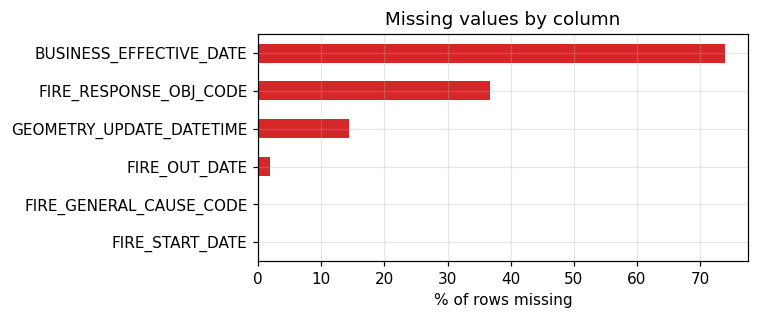

In [6]:
missing = df[raw.columns].isna().sum().rename("missing").to_frame()
missing["share_%"] = (100 * missing["missing"] / len(df)).round(2)
missing = missing[missing["missing"] > 0].sort_values("missing", ascending=False)
display(missing)

ax = missing["share_%"].plot.barh(figsize=(7, 3), color="tab:red")
ax.set_xlabel("% of rows missing"); ax.set_title("Missing values by column"); ax.invert_yaxis()
plt.tight_layout(); plt.show()

Missing values are not random. The next cell checks where they come from.

In [7]:
decade = (df["FIRE_YEAR"] // 10 * 10).rename("decade")
print("Missing cause, by fire type:")
display(df[df["FIRE_GENERAL_CAUSE_CODE"].isna()]["FIRE_TYPE_CODE"].value_counts().to_frame("rows"))
print("Share of rows with no response objective, by decade:")
display(df["FIRE_RESPONSE_OBJ_CODE"].isna().groupby(decade).mean().round(2).to_frame("share_missing"))
print("Missing start dates, by year:")
display(df[df["FIRE_START_DATE"].isna()]["FIRE_YEAR"].value_counts().sort_index().to_frame("rows").T)

Missing cause, by fire type:


,rows
FIRE_TYPE_CODE,
PB,76


Share of rows with no response objective, by decade:


,share_missing
decade,
1970,1.00
1980,0.86
1990,0.00
2000,0.00
2010,0.00
2020,0.00


Missing start dates, by year:


FIRE_YEAR,1994,1995,1996,1997,1999,2000,2001,2003,2004,2005,2006,2007,2011,2014,2015
rows,6,8,4,6,2,7,4,1,1,1,2,1,2,3,1


- **Missing cause** happens only on prescribed burns, which have no cause by definition.
- **Missing response objective** covers almost all fires before 1990. The field was not recorded then, and we drop it anyway.
- **Missing start date** affects a few dozen fires. Without a start date a fire cannot be used as a daily label.
- **Missing out date** affects about 1,200 fires. That only matters for duration, not for ignition labels.
- The bookkeeping date columns are mostly empty and are not needed.

## Step 5. Dates and seasonality

Dates are stored as text like `2003/04/13 00:00:00+00`.

In [8]:
DATE_FMT = "%Y/%m/%d %H:%M:%S+00"
for col in ["FIRE_START_DATE", "FIRE_OUT_DATE"]:
    df[col] = pd.to_datetime(df[col], format=DATE_FMT, errors="coerce")

start = df["FIRE_START_DATE"]
print("Start dates range:", start.min().date(), "to", start.max().date())
print("Out dates range:  ", df["FIRE_OUT_DATE"].min().date(), "to", df["FIRE_OUT_DATE"].max().date())
print("Start times that are not exactly 00:00:", int((start.dt.hour.fillna(0) != 0).sum()))

Start dates range: 1976-03-28 to 2025-11-12
Out dates range:   1976-03-28 to 2025-11-19
Start times that are not exactly 00:00: 0


Every start time is exactly midnight. So the data gives the **day** a fire started, not the hour. That fits a daily ignition model. Hourly spread replays will need FIRMS detection times instead.

The `+00` suffix looks like UTC, but a midnight time on every row means these are calendar dates. Treat them as local dates and do not shift them by time zone.

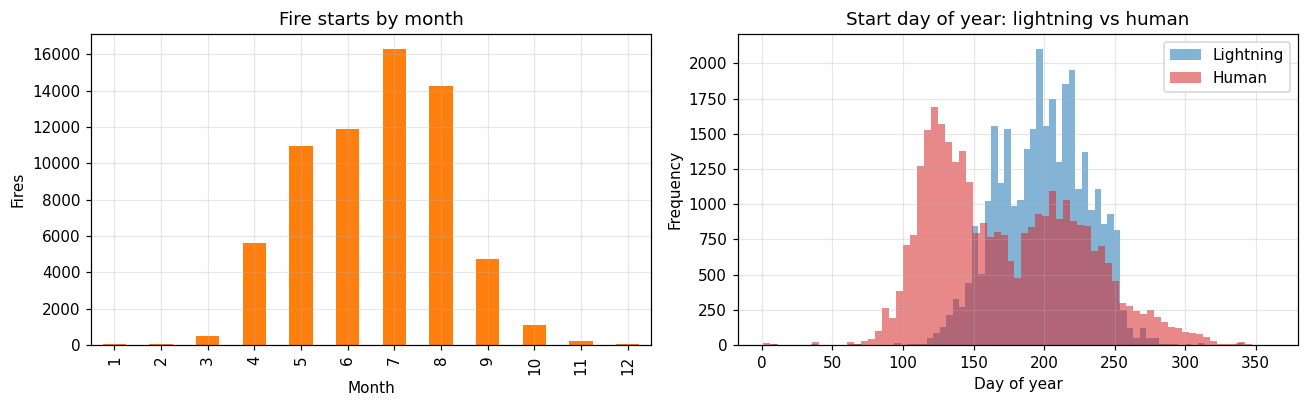

Share of fires starting April to September: 96.9%


In [9]:
df["start_month"] = start.dt.month.astype("Int64")
df["start_doy"] = start.dt.dayofyear
df["duration_days"] = (df["FIRE_OUT_DATE"] - start).dt.days

fig, axes = plt.subplots(1, 2, figsize=(12, 3.8))
df["start_month"].value_counts().sort_index().plot.bar(ax=axes[0], color="tab:orange")
axes[0].set_title("Fire starts by month"); axes[0].set_xlabel("Month"); axes[0].set_ylabel("Fires")

for grp, colr in [("Lightning", "tab:blue"), ("Human", "tab:red")]:
    df.loc[df["cause_group"].eq(grp), "start_doy"].plot.hist(bins=73, alpha=0.55, ax=axes[1], label=grp, color=colr)
axes[1].set_title("Start day of year: lightning vs human"); axes[1].set_xlabel("Day of year"); axes[1].legend()
plt.tight_layout(); plt.show()

share = df["start_month"].isin([4, 5, 6, 7, 8, 9]).mean()
print(f"Share of fires starting April to September: {share:.1%}")

The fire season runs from April to September. Human-caused fires peak in spring, before green-up, when dry grass and dead leaves burn easily. Lightning fires peak in July and August with summer storms.

This matters for the model: the two causes follow different calendars, so seasonality features and results by cause are both worth keeping.

In [10]:
print("Fire duration in days (out date minus start date):")
display(df["duration_days"].describe(percentiles=[0.5, 0.9, 0.99]).round(1).to_frame().T)

Fire duration in days (out date minus start date):


,count,mean,std,min,50%,90%,99%,max
duration_days,64435.0,5.7,52.3,-235.0,2.0,11.0,62.0,7365.0


Most fires are out within two days. The minimum is negative and the maximum is years long, so some dates are wrong. Step 11 looks at those.

## Step 6. Fires per year

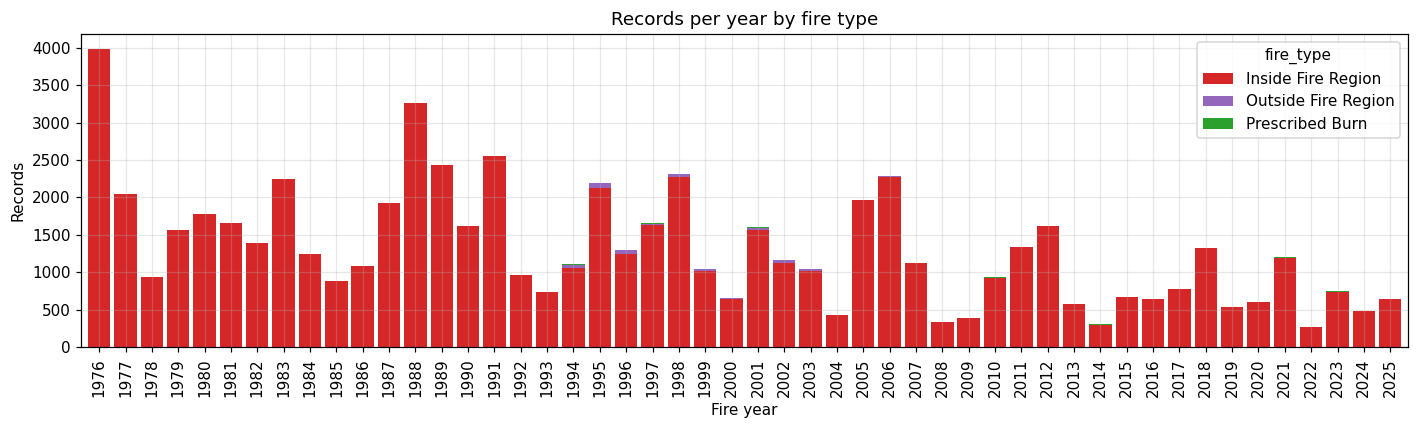

Years covered: 1976 to 2025 (50 seasons)
Wildfires per season: mean 1312, min 275 (2022), max 3981 (1976)


In [11]:
per_year = pd.crosstab(df["FIRE_YEAR"], df["fire_type"])
ax = per_year.plot.bar(stacked=True, figsize=(13, 4), width=0.85,
                       color={"Inside Fire Region": "tab:red", "Outside Fire Region": "tab:purple", "Prescribed Burn": "tab:green"})
ax.set_title("Records per year by fire type"); ax.set_xlabel("Fire year"); ax.set_ylabel("Records")
plt.tight_layout(); plt.show()

wild = df[df["FIRE_TYPE_CODE"].isin(["IFR", "OFR"])].copy()
per_season = wild.groupby("FIRE_YEAR").size()
print(f"Years covered: {df['FIRE_YEAR'].min()} to {df['FIRE_YEAR'].max()} ({df['FIRE_YEAR'].nunique()} seasons)")
print(f"Wildfires per season: mean {per_season.mean():.0f}, min {per_season.min()} ({per_season.idxmin()}), "
      f"max {per_season.max()} ({per_season.idxmax()})")

In [12]:
per_decade = wild.groupby(wild["FIRE_YEAR"] // 10 * 10).agg(
    seasons=("FIRE_YEAR", "nunique"), fires=("OGF_ID", "size"), hectares=("FIRE_FINAL_SIZE", "sum"))
per_decade["fires_per_season"] = (per_decade["fires"] / per_decade["seasons"]).round(0)
for grp in ["Human", "Lightning"]:
    n = wild[wild["cause_group"].eq(grp)].groupby(wild["FIRE_YEAR"] // 10 * 10).size()
    per_decade[f"{grp.lower()}_per_season"] = (n / per_decade["seasons"]).round(0)
per_decade["hectares"] = per_decade["hectares"].round(0)
per_decade.index.name = "decade"
per_decade

,seasons,fires,hectares,fires_per_season,human_per_season,lightning_per_season
decade,,,,,,
1970,4,8534,1032004.0,2134.0,1226.0,868.0
1980,10,17901,2324633.0,1790.0,1033.0,715.0
1990,10,15479,2804856.0,1548.0,812.0,708.0
2000,10,10980,779624.0,1098.0,432.0,644.0
2010,10,8727,1628261.0,873.0,377.0,479.0
2020,6,3955,1934637.0,659.0,221.0,428.0


The file covers 50 seasons, from 1976 to 2025. The number of fires swings widely from year to year, and it has fallen since the 1980s. Two things to keep in mind:

- **Year-to-year swings** mean one test season can be unusually quiet or busy. Results should be reported per season.
- **The long-term drop** comes mostly from human-caused fires, which fell far more than lightning fires since the 1970s. Better prevention and detection likely explain this. Training on very old seasons may teach the model an outdated base rate. Our weather data (ERA5-Land) and satellite data (VIIRS, from 2012) make recent seasons the most useful anyway.

Outside-fire-region records appear mainly in the 1990s and 2000s.

## Step 7. Causes

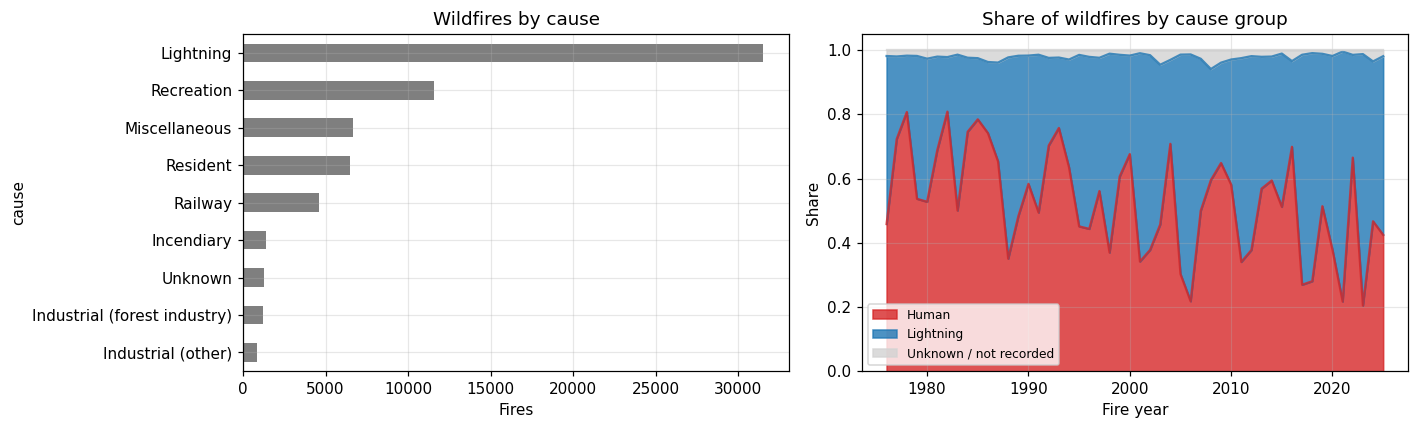

In [13]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
wild["cause"].value_counts().plot.barh(ax=axes[0], color="tab:gray")
axes[0].invert_yaxis(); axes[0].set_title("Wildfires by cause"); axes[0].set_xlabel("Fires")

cause_year = pd.crosstab(wild["FIRE_YEAR"], wild["cause_group"], normalize="index")
cause_year.plot.area(ax=axes[1], color={"Human": "tab:red", "Lightning": "tab:blue", "Unknown / not recorded": "lightgray"}, alpha=0.8)
axes[1].set_title("Share of wildfires by cause group"); axes[1].set_ylabel("Share"); axes[1].set_xlabel("Fire year")
axes[1].legend(loc="lower left", fontsize=8)
plt.tight_layout(); plt.show()

In [14]:
size_by_cause = wild.groupby("cause").agg(
    fires=("OGF_ID", "size"),
    median_ha=("FIRE_FINAL_SIZE", "median"),
    total_ha=("FIRE_FINAL_SIZE", "sum"),
)
size_by_cause["share_of_area_%"] = (100 * size_by_cause["total_ha"] / size_by_cause["total_ha"].sum()).round(1)
size_by_cause.sort_values("total_ha", ascending=False).round(1)

,fires,median_ha,total_ha,share_of_area_%
cause,,,,
Lightning,31503,0.2,9003491.1,85.7
Resident,6492,0.3,379897.7,3.6
Miscellaneous,6685,0.1,281673.5,2.7
Industrial (forest industry),1236,0.1,245623.1,2.3
Unknown,1300,0.2,239447.8,2.3
Recreation,11561,0.1,156976.0,1.5
Railway,4588,0.3,156366.7,1.5
Industrial (other),834,0.2,29081.7,0.3
Incendiary,1377,0.2,11457.1,0.1


Lightning starts about half the fires but burns most of the area. Lightning fires are often remote and are found later, so they grow larger.

Our model has no lightning data, which is out of scope. It predicts whether conditions favour ignition, not whether a strike happens. Reporting precision separately for lightning and human causes will show how much that limits us.

## Step 8. Fire size

,fires,share_of_fires_%,share_of_area_%
FIRE_FINAL_SIZE,,,
0 ha,7,0.0,0.0
0–0.1,30154,46.0,0.0
0.1–1,20814,31.7,0.1
1–10,9291,14.2,0.3
10–40,1935,3.0,0.4
40–200,1360,2.1,1.3
200–1k,964,1.5,4.4
1k–10k,809,1.2,26.3
>10k,242,0.4,67.2


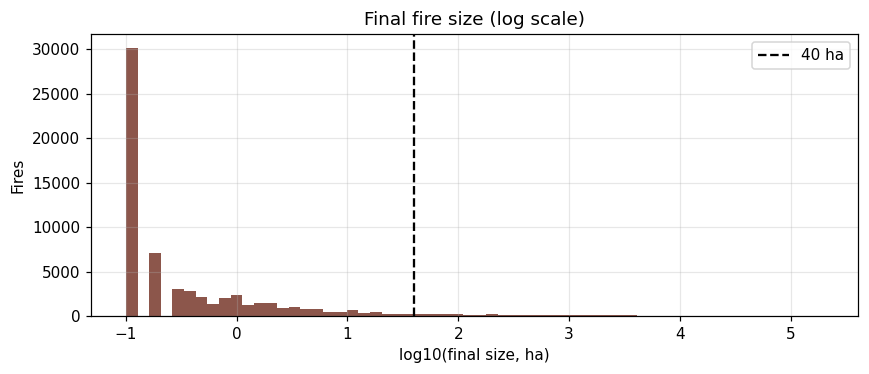

In [15]:
size = wild["FIRE_FINAL_SIZE"]
bins = [-0.001, 0, 0.1, 1, 10, 40, 200, 1_000, 10_000, np.inf]
labels = ["0 ha", "0–0.1", "0.1–1", "1–10", "10–40", "40–200", "200–1k", "1k–10k", ">10k"]
size_class = pd.cut(size, bins=bins, labels=labels)
size_table = size_class.value_counts().sort_index().rename("fires").to_frame()
size_table["share_of_fires_%"] = (100 * size_table["fires"] / len(size)).round(1)
size_table["share_of_area_%"] = (100 * size.groupby(size_class, observed=False).sum() / size.sum()).round(1)
display(size_table)

fig, ax = plt.subplots(figsize=(8, 3.5))
ax.hist(np.log10(size[size > 0]), bins=60, color="tab:brown")
ax.axvline(np.log10(40), color="k", ls="--", label="40 ha")
ax.set_xlabel("log10(final size, ha)"); ax.set_ylabel("Fires"); ax.set_title("Final fire size (log scale)"); ax.legend()
plt.tight_layout(); plt.show()

In [16]:
big = wild[wild["FIRE_FINAL_SIZE"] > 40]
print(f"Wildfires over 40 ha: {len(big):,} ({len(big)/len(wild):.1%} of fires, "
      f"{big['FIRE_FINAL_SIZE'].sum()/wild['FIRE_FINAL_SIZE'].sum():.1%} of burned area)")
print("Wildfires over 40 ha per decade:", big.groupby(big["FIRE_YEAR"] // 10 * 10).size().to_dict())
print("\nTen largest fires:")
wild.nlargest(10, "FIRE_FINAL_SIZE")[["FIRE_DISTURBANCE_AREA_IDENT", "FIRE_YEAR", "FIRE_START_DATE", "cause", "FIRE_FINAL_SIZE", "Y", "X"]]

Wildfires over 40 ha: 3,375 (5.1% of fires, 99.2% of burned area)
Wildfires over 40 ha per decade: {1970: 343, 1980: 786, 1990: 960, 2000: 413, 2010: 520, 2020: 353}

Ten largest fires:


,FIRE_DISTURBANCE_AREA_IDENT,FIRE_YEAR,FIRE_START_DATE,cause,FIRE_FINAL_SIZE,Y,X
65473,RED12,2025,2025-05-28,Resident,196974.1,52.6561,-94.0710
61733,KEN51,2021,2021-06-05,Lightning,191810.6,50.6897,-95.0167
63408,RED16,2021,2021-05-27,Lightning,158737.3,51.3855,-94.9221
63429,SLK70,2011,2011-07-07,Lightning,141000.0,52.4429,-90.8143
61821,RED150,1983,1983-08-26,Lightning,132975.8,51.8203,-95.0972
60688,THU46,1980,1980-06-16,Miscellaneous,126747.7,49.6953,-90.1124
62421,RED27,1988,1988-05-30,Lightning,120625.0,52.0734,-93.2043
62757,KEN23,1980,1980-05-04,Lightning,113514.4,49.7265,-94.1125
60831,NIP136,1995,1995-08-09,Lightning,113152.0,51.0170,-87.0071
60864,SLK35,2011,2011-06-06,Lightning,112000.0,51.0941,-89.7312


**Key finding: the point layer includes large fires.** Our project context says the point layer only covers fires under 40 ha. That is not true for this download. Fires over 40 ha have points in every decade. The official page says the layer holds *"ignition points for forest fires of all sizes"*, and fires over 40 ha are *also* mapped as Area polygons.

So most large fires already have an official ignition point, and we may not need FIRMS to estimate them. The next check, once the Area layer is downloaded, is how many Area polygons have **no** matching point. Harsh needs to know this, because it shrinks the FIRMS ignition task.

Sizes are heavily skewed. Most fires stay under 1 ha, while a small number of large fires hold nearly all the burned area. The few 0 ha records are likely fires put out immediately or a recording gap.

## Step 9. Where the fires are

A quick map uses longitude and latitude directly, with the aspect ratio corrected for latitude. geopandas is not needed for this.

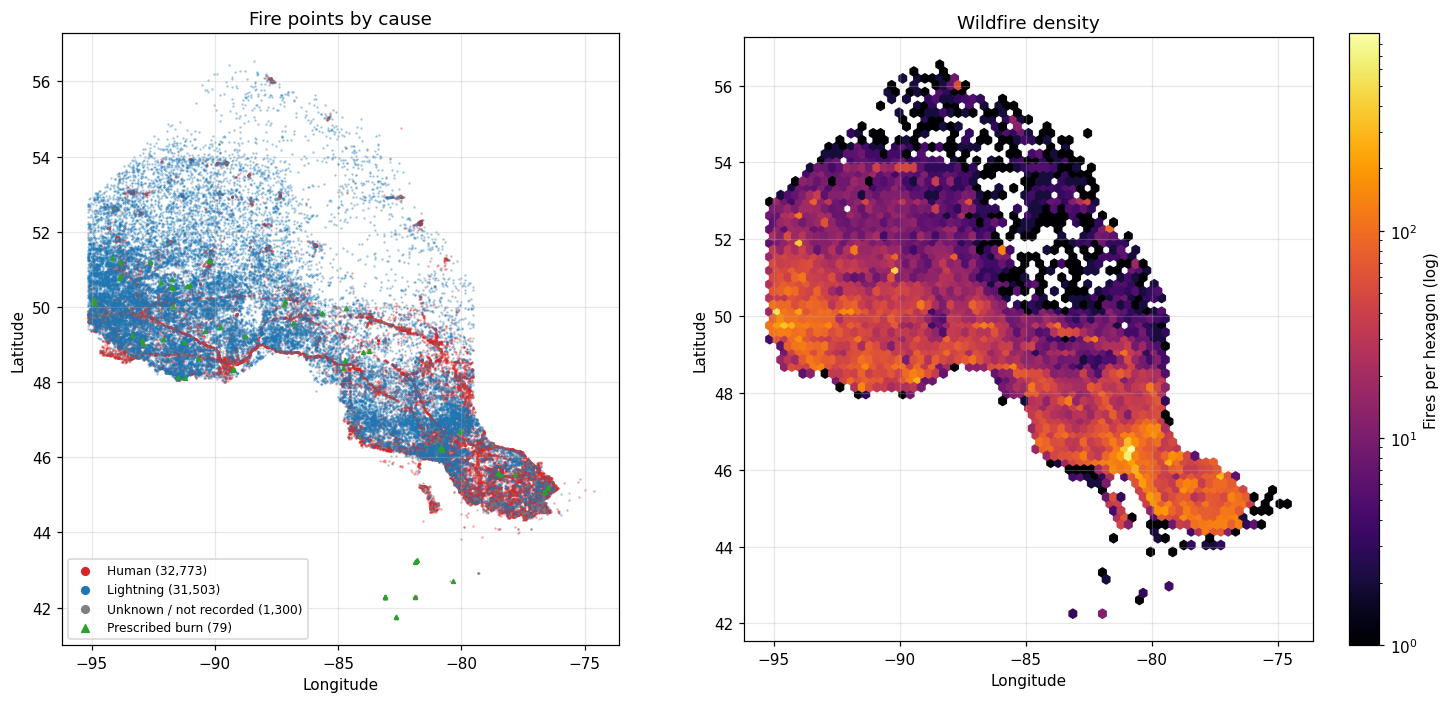

In [17]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6.5))
aspect = 1 / np.cos(np.deg2rad(49))

colors = {"Lightning": "tab:blue", "Human": "tab:red", "Unknown / not recorded": "gray"}
for grp, sub in df[df["FIRE_TYPE_CODE"].ne("PB")].groupby("cause_group"):
    axes[0].scatter(sub["X"], sub["Y"], s=0.3, alpha=0.4, color=colors[grp], label=f"{grp} ({len(sub):,})")
pb = df[df["FIRE_TYPE_CODE"].eq("PB")]
axes[0].scatter(pb["X"], pb["Y"], s=6, color="tab:green", marker="^", label=f"Prescribed burn ({len(pb)})")
axes[0].set_title("Fire points by cause")
leg = axes[0].legend(fontsize=8, loc="lower left")
for h in leg.legend_handles:
    h.set_sizes([25]); h.set_alpha(1)

hb = axes[1].hexbin(wild["X"], wild["Y"], gridsize=70, bins="log", cmap="inferno", mincnt=1)
fig.colorbar(hb, ax=axes[1], label="Fires per hexagon (log)")
axes[1].set_title("Wildfire density")

for ax in axes:
    ax.set_aspect(aspect); ax.set_xlabel("Longitude"); ax.set_ylabel("Latitude")
plt.tight_layout(); plt.show()

In [18]:
print("Latitude by fire type:")
display(df.groupby("fire_type")["Y"].describe()[["count", "min", "25%", "50%", "max"]].round(2))
in_box = df["X"].between(-95.2, -74.3).all() and df["Y"].between(41.6, 56.9).all()
print("Coordinates all inside a rough Ontario box (lon -95.2 to -74.3, lat 41.6 to 56.9):", bool(in_box))

Latitude by fire type:


,count,min,25%,50%,max
fire_type,,,,,
Inside Fire Region,65205.0,44.32,46.46,48.70,56.55
Outside Fire Region,371.0,42.25,54.02,54.44,56.43
Prescribed Burn,79.0,41.74,45.37,49.02,51.32


Coordinates all inside a rough Ontario box (lon -95.2 to -74.3, lat 41.6 to 56.9): True


- **Human fires** trace clear lines along highways and rail corridors, and cluster in the south-east near towns.
- **Lightning fires** dominate the northwest and thin out north of about 53° N, where there are fewer records overall.
- **Outside-fire-region fires** sit mostly in the Far North, around 54° N. That area lay outside the managed fire region when those fires were recorded.
- **Prescribed burns** are few and scattered, including a handful near Lake Erie, far south of the fire region.
- **Coordinates** all fall inside Ontario, with no swapped or zero values.

The fire-region boundary has moved over the years, so the type code is a historical label. We should clip every record to one fixed study area, Ontario's Fire Management Zone layer, and not rely on this code for that.

## Step 10. The fire identifier

The official description says the ID is the district code plus a fire number, and fires are numbered through each season. So the number restarts every year.

In [19]:
df["district"] = df["FIRE_DISTURBANCE_AREA_IDENT"].str.extract(r"^([A-Z]+)")[0]
df["fire_number"] = df["FIRE_DISTURBANCE_AREA_IDENT"].str.extract(r"(\d+)$")[0].astype(int)
print("Share of IDs matching 3 letters + number:", df["FIRE_DISTURBANCE_AREA_IDENT"].str.fullmatch(r"[A-Z]{3}\d+").mean())
print("Distinct districts:", df["district"].nunique())
print("Most repeated IDs (ID alone is NOT unique):", df["FIRE_DISTURBANCE_AREA_IDENT"].value_counts().head(3).to_dict())
print("OGF_ID unique on every row:", df["OGF_ID"].is_unique)

for key in [["FIRE_DISTURBANCE_AREA_IDENT", "FIRE_YEAR"], ["FIRE_DISTURBANCE_AREA_IDENT", "FIRE_YEAR", "FIRE_TYPE_CODE"]]:
    dup = df.duplicated(key, keep=False)
    print(f"\nKey {key}: {dup.sum()} rows share a key with another row")

Share of IDs matching 3 letters + number: 1.0
Distinct districts: 49
Most repeated IDs (ID alone is NOT unique): {'KEN1': 61, 'COC1': 61, 'COC2': 60}
OGF_ID unique on every row: True

Key ['FIRE_DISTURBANCE_AREA_IDENT', 'FIRE_YEAR']: 788 rows share a key with another row

Key ['FIRE_DISTURBANCE_AREA_IDENT', 'FIRE_YEAR', 'FIRE_TYPE_CODE']: 0 rows share a key with another row


In [20]:
key_year = ["FIRE_DISTURBANCE_AREA_IDENT", "FIRE_YEAR"]
shared = df[df.duplicated(key_year, keep=False)]
pairs = shared.groupby(key_year)["FIRE_TYPE_CODE"].agg(lambda s: " + ".join(sorted(s)))
print("Which fire types share an ID within the same year:")
display(pairs.value_counts().rename("ID-year groups").to_frame())
print("Districts involved:", shared["district"].value_counts().head(5).to_dict())
shared.sort_values(key_year)[key_year + ["FIRE_TYPE_CODE", "X", "Y", "FIRE_START_DATE", "FIRE_FINAL_SIZE"]].head(6)

Which fire types share an ID within the same year:


,ID-year groups
FIRE_TYPE_CODE,
IFR + OFR,329
IFR + PB,59
OFR + PB,3
IFR + OFR + PB,2


Districts involved: {'COC': 436, 'SLK': 138, 'KEM': 32, 'MID': 26, 'RED': 26}


,FIRE_DISTURBANCE_AREA_IDENT,FIRE_YEAR,FIRE_TYPE_CODE,X,Y,FIRE_START_DATE,FIRE_FINAL_SIZE
64037,APK1,2023,PB,-78.5000,45.5758,2023-04-27,9.1
64498,APK1,2023,IFR,-78.3869,46.0884,2023-05-14,0.1
64543,APK1,2024,PB,-78.4197,45.5354,2024-04-17,8.0
64868,APK1,2024,IFR,-78.4967,45.5615,2024-06-15,0.1
64054,APK2,2023,PB,-78.5048,45.5736,2023-05-06,9.7
64355,APK2,2023,IFR,-78.4203,45.5491,2023-05-28,0.2


- **The ID repeats across years**, so a fire must be identified by ID **plus** year.
- **Within one year, an ID repeats only across fire types.** Inside-region fires, outside-region fires and prescribed burns are each numbered separately. For example, APK1 in 2023 is both a prescribed burn and a recreation fire. Most shared IDs are Cochrane inside-region and outside-region fires from the 1990s and early 2000s.
- **ID + year + type is unique on every row.**

**Recommendation:** use `OGF_ID` as the record key. Use ID + year + type to match points to the Area layer, after checking which of these fields the Area layer carries.

## Step 11. Data-quality problems

### 11a. The 2003 season has swapped day and month values

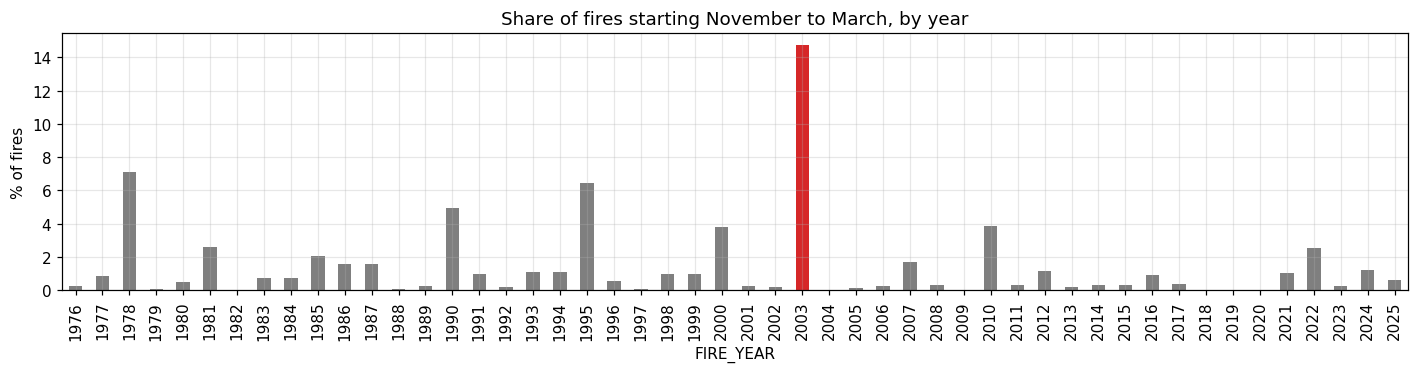

2003: 14.7% of fires start Nov-Mar.  Median of other years: 0.5%


In [21]:
off_season = df["start_month"].isin([11, 12, 1, 2, 3])
winter_share = off_season.groupby(df["FIRE_YEAR"]).mean()
ax = (100 * winter_share).plot.bar(figsize=(13, 3.5), color=np.where(winter_share.index == 2003, "tab:red", "tab:gray"))
ax.set_ylabel("% of fires"); ax.set_title("Share of fires starting November to March, by year")
plt.tight_layout(); plt.show()
print(f"2003: {winter_share.loc[2003]:.1%} of fires start Nov-Mar.  Median of other years: {winter_share.drop(2003).median():.1%}")

In [22]:
y03 = df[df["FIRE_YEAR"].eq(2003)]
bad03 = y03[y03["FIRE_OUT_DATE"] < y03["FIRE_START_DATE"]]

def swap_day_month(s):
    return pd.to_datetime(dict(year=s.dt.year, month=s.dt.day, day=s.dt.month), errors="coerce")

fixed = swap_day_month(bad03["FIRE_START_DATE"])
print(f"2003 fires whose out date is before the start date: {len(bad03)}")
print(f"...of which swapping the start day and month makes the dates valid: {(fixed <= bad03['FIRE_OUT_DATE']).sum()}")
bad03[["FIRE_DISTURBANCE_AREA_IDENT", "FIRE_START_DATE", "FIRE_OUT_DATE", "FIRE_FINAL_SIZE"]].head(6)

2003 fires whose out date is before the start date: 69
...of which swapping the start day and month makes the dates valid: 40


,FIRE_DISTURBANCE_AREA_IDENT,FIRE_START_DATE,FIRE_OUT_DATE,FIRE_FINAL_SIZE
16,NIP34,2003-12-06,2003-06-16,0.5
23,NIP40,2003-11-06,2003-06-21,2.5
45,NIP63,2003-06-30,2003-02-07,0.1
48,NIP66,2003-09-07,2003-07-13,2.5
49,NIP67,2003-11-07,2003-07-13,0.3
62,NIP83,2003-11-08,2003-08-15,2.5


In 2003 far too many fires start in winter, and many end before they start. A start of 2003-12-06 with an out date of 2003-06-16 makes sense as 2003-06-12. The metadata says the fire archive was loaded from an older database covering 1960 to 2003, so this season was probably entered with day-first dates.

A date with day 13 or later can't be swapped, so not every 2003 date is wrong. But any 2003 date with a day of 12 or less is ambiguous. **Recommendation:** leave 2003 out of training and testing. It is outside our preferred VIIRS-era seasons anyway.

### 11b. Other impossible dates

In [23]:
neg = df[df["duration_days"] < 0]
print(f"Out date before start date: {len(neg)} rows. By year: {neg['FIRE_YEAR'].value_counts().sort_index().to_dict()}")

mismatch = df["FIRE_START_DATE"].notna() & (df["FIRE_START_DATE"].dt.year != df["FIRE_YEAR"])
# Holdover: found in autumn, smouldered over winter, declared out next season
holdover = mismatch & (df["start_month"] >= 10) & (df["FIRE_YEAR"] == df["FIRE_START_DATE"].dt.year + 1)
start_year_typo = mismatch & ~holdover
cols = ["FIRE_DISTURBANCE_AREA_IDENT", "FIRE_YEAR", "FIRE_START_DATE", "FIRE_OUT_DATE", "FIRE_FINAL_SIZE"]
print(f"\nStart year differs from FIRE_YEAR: {mismatch.sum()} rows")
print(f"  Over-winter holdovers (start Oct-Dec, FIRE_YEAR = next year): {holdover.sum()}")
display(df.loc[holdover, cols])
print(f"  Other mismatches (likely start-year typos): {start_year_typo.sum()}")
display(df.loc[start_year_typo, cols])

very_long = df[df["duration_days"] > 365]
print(f"Fires lasting more than a year: {len(very_long)} rows")
display(very_long[["FIRE_DISTURBANCE_AREA_IDENT", "FIRE_YEAR", "FIRE_START_DATE", "FIRE_OUT_DATE", "FIRE_FINAL_SIZE"]])

Out date before start date: 153 rows. By year: {1976: 23, 1977: 1, 1978: 3, 1979: 8, 1980: 7, 1981: 12, 1982: 8, 1983: 1, 1984: 1, 1985: 2, 1986: 1, 1987: 2, 1990: 1, 1994: 1, 1995: 1, 1998: 1, 1999: 1, 2001: 1, 2003: 69, 2012: 1, 2013: 1, 2018: 1, 2022: 1, 2023: 2, 2024: 2, 2025: 1}

Start year differs from FIRE_YEAR: 14 rows
  Over-winter holdovers (start Oct-Dec, FIRE_YEAR = next year): 10


,FIRE_DISTURBANCE_AREA_IDENT,FIRE_YEAR,FIRE_START_DATE,FIRE_OUT_DATE,FIRE_FINAL_SIZE
5571,FOR1,2007,2006-11-15,2007-04-24,3.0
9517,DRY3,2012,2011-12-05,2012-03-28,0.1
9921,DRY2,2012,2011-12-05,2012-03-28,0.1
10965,DRY1,2012,2011-12-05,2012-03-28,0.2
54540,NIP37,2013,2012-11-15,2013-06-25,0.1
55785,THU5,2016,2015-10-30,2016-05-03,0.1
59896,THU10,2021,2020-11-26,2021-05-24,17.0
65007,THU10,2025,2024-11-23,2025-05-31,0.1
65130,THU8,2025,2024-11-21,2025-05-26,1.2
65641,THU11,2025,2024-11-21,2025-05-31,0.1


  Other mismatches (likely start-year typos): 4


,FIRE_DISTURBANCE_AREA_IDENT,FIRE_YEAR,FIRE_START_DATE,FIRE_OUT_DATE,FIRE_FINAL_SIZE
1605,DRY1,2005,2004-04-14,2005-04-14,0.5
2456,THU4,2005,2004-04-15,2005-04-15,0.1
6877,THU2,2008,2007-04-16,2008-04-17,0.1
55784,PAR18,2016,2012-06-19,2016-06-20,0.4


Fires lasting more than a year: 6 rows


,FIRE_DISTURBANCE_AREA_IDENT,FIRE_YEAR,FIRE_START_DATE,FIRE_OUT_DATE,FIRE_FINAL_SIZE
343,DRY11,2003,2003-04-05,2005-04-05,0.1
6877,THU2,2008,2007-04-16,2008-04-17,0.1
55784,PAR18,2016,2012-06-19,2016-06-20,0.4
60922,RED8,1977,1977-05-13,1997-07-12,57174.0
62645,RED24,1977,1977-05-21,1997-07-12,28166.1
63751,RED42,1977,1977-06-16,1997-07-12,4079.2


- **Most year mismatches are over-winter holdovers.** These fires were found in October to December, smouldered under snow and were declared out the next spring. They are filed under the year they went out. Their **start date** is the correct label date, not `FIRE_YEAR`.
- **The other mismatches look like start-year typos.** Their start and out dates fall on nearly the same day of the year, one or more years apart, and `FIRE_YEAR` matches the out date. The start year is probably wrong, so drop these few rows from the labels.
- **Fires lasting more than a year** are typos in the start year or the out year. For example, the three Red Lake 1977 fires show an out date of 1997-07-12, which was probably meant to be 1977.
- **Out dates before start dates** outside 2003 are few and mostly in the 1970s and 1980s.

Apart from the start-year typos, these errors affect duration but not the ignition label, so we flag them rather than drop them.

### 11c. Several fires at exactly the same point on the same day

In [24]:
same = df[df.duplicated(["X", "Y", "FIRE_START_DATE"], keep=False) & df["FIRE_START_DATE"].notna()]
print(f"Rows sharing exact coordinates and start date with another row: {len(same):,}")
share_diff_id = (same.groupby(["X", "Y", "FIRE_START_DATE"])["FIRE_DISTURBANCE_AREA_IDENT"].nunique() > 1).mean()
print(f"Groups where the fire IDs differ (separate reports, not copies): {share_diff_id:.1%}")
print("By decade:", same.groupby(same["FIRE_YEAR"] // 10 * 10).size().to_dict())
print("Rows identical on every attribute except the ID columns:",
      df.duplicated([c for c in raw.columns if c not in ("OGF_ID", "OBJECTID")]).sum())

Rows sharing exact coordinates and start date with another row: 1,234
Groups where the fire IDs differ (separate reports, not copies): 100.0%
By decade: {1970: 400, 1980: 574, 1990: 195, 2000: 54, 2010: 11}
Rows identical on every attribute except the ID columns: 0


These rows have different fire numbers and sizes, so they are separate fires, not copied rows. They are concentrated before 1990, probably because older locations were recorded coarsely and nearby fires ended up with the same coordinates. For a daily grid-cell label, several fires in one cell on one day count as one positive, so this does not hurt the label.

### 11d. Coordinate precision

In [25]:
decimals = df["X"].astype(str).str.split(".").str[1].str.len()
precision = pd.crosstab(df["FIRE_YEAR"] // 10 * 10, decimals)
precision.columns = [f"{c} decimals" for c in precision.columns]
precision.index.name = "decade"
display(precision)
print("Approximate position error in longitude at 49 N: 1 decimal = +/-4 km, 2 = +/-400 m, 3 = +/-40 m, 4 = +/-4 m")

,1 decimals,2 decimals,3 decimals,4 decimals,13 decimals
decade,,,,,
1970,0,0,60,8474,0
1980,27,39,655,17107,73
1990,35,127,1363,13711,265
2000,20,85,1028,9687,180
2010,9,72,796,7724,145
2020,6,47,356,3501,63


Approximate position error in longitude at 49 N: 1 decimal = +/-4 km, 2 = +/-400 m, 3 = +/-40 m, 4 = +/-4 m


Most points have 4 decimals, which is a few metres. A few hundred have only 1 or 2 decimals, so they could be off by up to about 4 km. Rows with 13 decimals were probably converted from another coordinate system. On a 10 km grid, only the 1-decimal rows matter. Flag rows with 2 or fewer decimals as *low location precision*.

Note that a value like `-88.5` also prints with 1 decimal, so a few of these may be exact by chance. The flag is a warning, not proof.

### 11e. Zero-size fires

In [26]:
zero = df[df["FIRE_FINAL_SIZE"].eq(0)]
print(f"Fires with final size 0 ha: {len(zero)}")
zero[["FIRE_DISTURBANCE_AREA_IDENT", "FIRE_YEAR", "fire_type", "cause", "FIRE_START_DATE"]]

Fires with final size 0 ha: 7


,FIRE_DISTURBANCE_AREA_IDENT,FIRE_YEAR,fire_type,cause,FIRE_START_DATE
11340,DRY11,1996,Inside Fire Region,Lightning,1996-06-12
17095,DRY32,1996,Inside Fire Region,Lightning,1996-06-13
33554,NIP49,1999,Inside Fire Region,Lightning,1999-06-19
40350,DRY35,1996,Inside Fire Region,Lightning,1996-06-12
46372,DRY25,1996,Inside Fire Region,Lightning,1996-06-12
64330,HEA20,2023,Inside Fire Region,Lightning,2023-09-01
65082,RED27,2025,Inside Fire Region,Lightning,2025-06-17


Very few. They are still ignitions, so keep them as labels.

## Step 12. Columns that would leak the answer

`FIRE_WEATHER_INDEX` and `FIRE_RESPONSE_OBJ_CODE` exist **only because a fire happened**. Non-fire grid cells have no such values, so a model given these columns could learn that *having an FWI value means fire*. The response objective is also decided after ignition.

FWI exactly 0: 8.1% of wildfires (likely 'not recorded' rather than a true zero)


,count,mean,50%,max
cause_group,,,,
Human,32773.0,10.8,10.0,80.0
Lightning,31503.0,12.2,11.0,86.5
Unknown / not recorded,1300.0,10.8,10.0,50.0


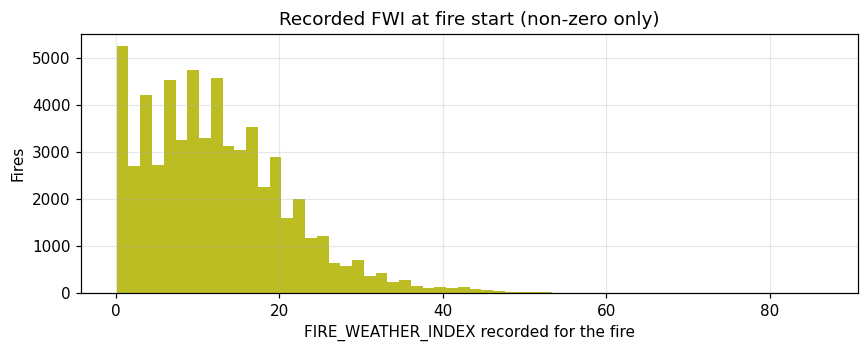

In [27]:
fwi = wild["FIRE_WEATHER_INDEX"]
print(f"FWI exactly 0: {(fwi == 0).mean():.1%} of wildfires (likely 'not recorded' rather than a true zero)")
display(wild.groupby("cause_group")["FIRE_WEATHER_INDEX"].describe()[["count", "mean", "50%", "max"]].round(1))

fig, ax = plt.subplots(figsize=(8, 3.3))
ax.hist(fwi[fwi > 0], bins=60, color="tab:olive")
ax.set_xlabel("FIRE_WEATHER_INDEX recorded for the fire"); ax.set_ylabel("Fires"); ax.set_title("Recorded FWI at fire start (non-zero only)")
plt.tight_layout(); plt.show()

**Decision:** drop both columns from the model features. We compute FWI ourselves from ERA5-Land for *every* cell and day, fire or not.

The recorded FWI is still useful as a **cross-check**. Once Manav's ERA5-Land FWI table exists, comparing our computed FWI at these fire points with the recorded values will show whether the FWI calculation is right.

## Step 13. Summary: problems found and proposed cleaning rules

In [28]:
flags = pd.DataFrame(index=df.index)
flags["prescribed_burn"] = df["FIRE_TYPE_CODE"].eq("PB")
flags["missing_start_date"] = df["FIRE_START_DATE"].isna()
flags["season_2003_ambiguous_date"] = df["FIRE_YEAR"].eq(2003)
flags["out_before_start"] = df["duration_days"] < 0
flags["duration_over_365d"] = df["duration_days"] > 365
flags["overwinter_holdover"] = holdover
flags["start_year_typo"] = start_year_typo
flags["low_location_precision"] = decimals <= 2
flags["same_point_same_day"] = df.duplicated(["X", "Y", "FIRE_START_DATE"], keep=False) & df["FIRE_START_DATE"].notna()
flags["size_zero"] = df["FIRE_FINAL_SIZE"].eq(0)

action = {
    "prescribed_burn": "Drop from ignition labels",
    "missing_start_date": "Drop from ignition labels",
    "season_2003_ambiguous_date": "Exclude 2003 from train/test",
    "out_before_start": "Keep label; set duration to missing",
    "duration_over_365d": "Keep label; set duration to missing",
    "overwinter_holdover": "Keep; use start date as label date",
    "start_year_typo": "Drop from ignition labels",
    "low_location_precision": "Keep; flag, check against grid size",
    "same_point_same_day": "Keep; collapses to one positive cell-day",
    "size_zero": "Keep",
}
summary = flags.sum().rename("rows").to_frame()
summary["share_%"] = (100 * summary["rows"] / len(df)).round(2)
summary["proposed_action"] = summary.index.map(action)
summary

,rows,share_%,proposed_action
prescribed_burn,79,0.12,Drop from ignition labels
missing_start_date,49,0.07,Drop from ignition labels
season_2003_ambiguous_date,1040,1.58,Exclude 2003 from train/test
out_before_start,153,0.23,Keep label; set duration to missing
duration_over_365d,6,0.01,Keep label; set duration to missing
overwinter_holdover,10,0.02,Keep; use start date as label date
start_year_typo,4,0.01,Drop from ignition labels
low_location_precision,467,0.71,"Keep; flag, check against grid size"
same_point_same_day,1234,1.88,Keep; collapses to one positive cell-day
size_zero,7,0.01,Keep


In [29]:
usable = ~(flags["prescribed_burn"] | flags["missing_start_date"]
           | flags["season_2003_ambiguous_date"] | flags["start_year_typo"])
label_rows = df[usable]
print(f"Records usable as ignition labels: {usable.sum():,} of {len(df):,}")
print(f"Seasons: {label_rows['FIRE_YEAR'].min()}-{label_rows['FIRE_YEAR'].max()} (excluding 2003)")
viirs = label_rows[label_rows["FIRE_YEAR"].between(2012, 2025)]
print(f"Of these, in the VIIRS era 2012-2025: {len(viirs):,} fires "
      f"({viirs['cause_group'].eq('Lightning').mean():.0%} lightning, {viirs['cause_group'].eq('Human').mean():.0%} human)")
display(viirs.groupby("FIRE_YEAR").size().rename("fires").to_frame().T)

Records usable as ignition labels: 64,524 of 65,655
Seasons: 1976-2025 (excluding 2003)
Of these, in the VIIRS era 2012-2025: 10,416 fires (59% lightning, 39% human)


FIRE_YEAR,2012,2013,2014,2015,2016,2017,2018,2019,2020,2021,2022,2023,2024,2025
fires,1621,582,303,668,647,776,1327,537,608,1198,275,743,486,645


### Problems found

1. **The point layer includes large fires.** This contradicts the project context. Most fires over 40 ha already have an official ignition point. Next, check the Area layer for polygons with no matching point.
2. **2003 dates are unreliable.** Day and month look swapped for part of that season. Exclude 2003 from training and testing.
3. **Start dates are day-only.** There is no start time, which fits a daily model. Hourly spread timing must come from FIRMS.
4. **The fire ID alone is not unique.** It restarts every year, and each fire type is numbered separately. ID + year + type is unique. Use `OGF_ID` as the record key.
5. **Some dates are impossible.** These include out dates before start dates and fires lasting years, which affect only duration. A few start years are typos, and those rows should be dropped from the labels. Over-winter holdovers are filed under the next year, so always use the start date as the label date.
6. **Location precision varies.** A few hundred points have only 1 or 2 decimals, which could be off by up to about 4 km.
7. **Two columns would leak the answer.** `FIRE_WEATHER_INDEX` and `FIRE_RESPONSE_OBJ_CODE` must be kept out of the features.
8. **The fire-region type code is historical.** Clip to a fixed study-area boundary instead.

### Next steps
- Download the **Fire Disturbance Area** layer. Match polygons to points on ID + year, and count polygons with no ignition point. Share this with Harsh.
- Write the cleaning script in `data/` using the rules in the table above. Save a clean table with decoded codes and the flag columns.
- Add this dataset's rows to the shared data dictionary.
- Once the grid is agreed with Parth, snap points to cells and build the daily positive labels.